# Проект. Исследование стартапов

## Введение

Проект посвящён анализу рынка венчурных инвестиций в технологические компании на основе исторических данных до 2014 года.

**Цель проекта** — помочь инвестору понять, в какие рыночные сегменты и на каких стадиях привлечения капитала вероятность «успешных» сделок выше.

**Задачи:**
1. Собрать и подготовить данные
2. Описать структуру рынка
3. Проанализировать объёмы финансирования
4. Выявить перспективные отрасли
5. Проанализировать типы финансирования
6. Сформулировать рекомендации

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

Файлы находятся в папке `datasets`, если вы выполняете работу на платформе. В случае, если вы делаете работу локально, доступ к файлам в папке можно получить по адресу `https://code.s3.yandex.net/datasets/` + имя файла.

### 1.1. Вывод общей информации



In [1]:
# Загружаем библиотеки
import pandas as pd

# Для визуализации
import matplotlib.pyplot as plt
import seaborn as sns

#Для расчета коэффициента корреляции
!pip install phik
from phik import phik_matrix

In [2]:
#Загружаем датасет (инветиции по компаниям)
df_1 = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)

In [3]:
#Загружаем датасет (возвраты средств)
df_2 =  pd.read_csv("https://code.s3.yandex.net/datasets/cb_returns.csv", sep=',')

In [4]:
#Выводим первые строки датафрейма df_1
df_1.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# Выводим информацию о датафрейме df_1
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [6]:
# Выводим количество пропусков в df_1
df_1.isna().sum()

name                     4857
homepage_url             8305
category_list            8817
 market                  8817
 funding_total_usd       4856
status                   6170
country_code            10129
state_code              24133
region                  10129
city                    10972
funding_rounds           4856
participants            23821
founded_at              15740
founded_month           15812
founded_quarter         15812
founded_year            15740
first_funding_at         4856
mid_funding_at          24006
last_funding_at          4856
seed                     4856
venture                  4856
equity_crowdfunding      4856
undisclosed              4856
convertible_note         4856
debt_financing           4856
angel                    4856
grant                    4856
private_equity           4856
post_ipo_equity          4856
post_ipo_debt            4856
secondary_market         4856
product_crowdfunding     4856
round_A                  4856
round_B   

В таблице cb_investments 54 294 записи и 40 столбцов. Даты пока представлены как строки, а столбец funding_total_usd хранится в текстовом формате с разделителями разрядов. Во многих столбцах (информация о сайте, сегменте рынка, датах и участниках раундов) присутствуют пропуски, которые потребуется обработать на этапе предобработки.

В таблице cb_investments значительная доля пропусков присутствует как в категориальных, так и в числовых признаках. Наиболее сильно пропуски затрагивают информацию о регионе (state_code, city, region), участниках раундов (participants), датах основания и среднем времени финансирования (mid_funding_at). Важный показатель funding_total_usd также заполнен не для всех компаний.

In [7]:
#Выводим первые строки датафрейма df_2
df_2.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [8]:
# Выводим информацию о датафрейме df_2
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


In [9]:
# Смотрим пропуски в df_2
df_2.isna().sum()

year                    0
seed                    0
venture                 0
equity_crowdfunding     0
undisclosed             0
convertible_note        0
debt_financing          0
angel                   0
grant                   0
private_equity          0
post_ipo_equity         0
post_ipo_debt           0
secondary_market        0
product_crowdfunding    0
dtype: int64

В таблице cb_returns 15 строк (годы с 2000 по 2014) и 14 столбцов. Столбец year имеет целочисленный тип, а показатели возвратов по типам финансирования представлены числовыми признаками без пропусков. Таблица компактная и готова к дальнейшему анализу, столбец year можно использовать как индекс.

В таблице cb_returns пропуски отсутствуют: для каждого года доступны значения возвратов по всем типам финансирования.

In [10]:
# создаем копию датасета df_1 до преобразования для возможности проверить сделанные изменения после предобработки
tmp_1 = df_1.copy()
len(tmp_1)

54294

In [11]:
# создаем копию датасета df_2 до преобразования для возможности проверить сделанные изменения после предобработки
tmp_2 = df_2.copy()
len(tmp_2)

15

### 1.2. Предобработка данных

In [12]:
# Проверяем названия df_1
df_1.columns

Index(['name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

In [13]:
# Удаляем лишние пробелы
df_1.columns = df_1.columns.str.strip()

In [14]:
# Проверяем 
df_1.columns

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

In [15]:
# Проверяем названия df_2
df_2.columns

Index(['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding'],
      dtype='object')

В датафрейме df_2 названия колонок оформлены в удобном формате

In [16]:
# Убираем выделение разрядом
df_1['funding_total_usd'] = df_1['funding_total_usd'].str.replace(',', '', regex=False)

In [17]:
df_1['funding_total_usd'].head()

0     90000000 
1      2000000 
2      9000000 
3      7700000 
4       540000 
Name: funding_total_usd, dtype: object

In [18]:
# Приводим столбец funding_total_usd к числовому формату
df_1['funding_total_usd'] = pd.to_numeric(df_1['funding_total_usd'], errors = 'coerce')

In [19]:
# Проверяем
df_1['funding_total_usd'].dtype

dtype('float64')

In [20]:
df_1['funding_total_usd'].head()

0    90000000.0
1     2000000.0
2     9000000.0
3     7700000.0
4      540000.0
Name: funding_total_usd, dtype: float64

В столбце funding_total_usd убраны разделители разрядов (запятые), значения успешно приведены к числовому типу float64.

In [21]:
# Приводим столбцы к datetime
for column in ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']:
    df_1[column] = pd.to_datetime (df_1[column], errors='coerce')

/tmp/ipykernel_625/338377561.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_1[column] = pd.to_datetime (df_1[column], errors='coerce')


In [22]:
df_1[['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   founded_at        38553 non-null  datetime64[ns]
 1   first_funding_at  49428 non-null  datetime64[ns]
 2   mid_funding_at    30288 non-null  datetime64[ns]
 3   last_funding_at   49432 non-null  datetime64[ns]
dtypes: datetime64[ns](4)
memory usage: 1.7 MB


Необходимые столбцы founded_at, first_funding_at, mid_funding_at и last_funding_at приведены к типу datetime64. 

In [23]:
# Столбец year делаем индексом датафрейма df_2
df_2 = df_2.set_index('year')
df_2.head()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [24]:
df_2.index

Index([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014],
      dtype='int64', name='year')

В таблице cb_returns столбец year перенесён в индекс (от 2000 до 2014), что удобно для выборок и построения временных рядов по годам.

In [25]:
# Заполняем заглушками
text_cols = ['name', 'homepage_url', 'category_list', 'market', 'country_code', 'state_code', 'region', 'city', 'status']

df_1[text_cols] = df_1[text_cols].fillna('unknown')

In [26]:
# Смотрим сколько полных дубликатов строк
df_1.duplicated().sum()

4855

In [27]:
# Удаляем полные дубликаты
df_1 = df_1.drop_duplicates()

In [28]:
# Проверяем 
df_1.duplicated().sum()

0

In [29]:
# Смотрим пропуски в funding_total_usd
df_1['funding_total_usd'].isna().sum()

8532

In [30]:
# Удаляем пропуски
df_1 = df_1.dropna(subset=['funding_total_usd'])

In [31]:
# Проверяем
df_1['funding_total_usd'].isna().sum()

0

После удаления 4 855 полных дубликатов в столбце funding_total_usd оставалось 8 532 пропуска. Эти строки удалены, так как не содержат информации о суммарном финансировании. В дальнейший анализ включены только компании с известным объёмом привлечённых средств.

In [32]:
# Считаем середину интервала между first_funding_at и last_funding_at
mid_calc = df_1['first_funding_at'] + (df_1['last_funding_at'] - df_1['first_funding_at']) / 2

# Заполняем пропуски в mid_funding_at 
df_1['mid_funding_at'] = df_1['mid_funding_at'].fillna(mid_calc)
                               

In [33]:
df_1['mid_funding_at'].isna().sum()

1

После заполнения mid_funding_at на основе first_funding_at и last_funding_at в столбце остался только один пропуск, вероятнее всего из‑за отсутствия одной из граничных дат. Общий уровень заполненности признака стал почти полным.

In [34]:
# Считаем долю пропусков по столбцам df_1
missing_percent = df_1.isna().sum() /len(df_1) * 100

missing_percent.sort_values(ascending=False)

participants            33.187474
founded_month           21.443763
founded_quarter         21.443763
founded_at              21.284866
founded_year            21.282421
first_funding_at         0.004889
mid_funding_at           0.002445
name                     0.000000
state_code               0.000000
country_code             0.000000
status                   0.000000
funding_total_usd        0.000000
market                   0.000000
category_list            0.000000
homepage_url             0.000000
funding_rounds           0.000000
city                     0.000000
region                   0.000000
last_funding_at          0.000000
seed                     0.000000
venture                  0.000000
equity_crowdfunding      0.000000
undisclosed              0.000000
convertible_note         0.000000
debt_financing           0.000000
angel                    0.000000
grant                    0.000000
private_equity           0.000000
post_ipo_equity          0.000000
post_ipo_debt 

In [35]:
# Проверим сколько удалено строк датасета
a = len(tmp_1)
b = len(df_1)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в исходном датасете 54294 
 Осталось строк в датасете после обработки 40907 
 Удалено строк в датасете после обработки 13387 
 Процент потерь 24.66


В исходном датасете было 54 294 строк, после предобработки осталось 40 907 строк, то есть было удалено 13 387 строк (24,66%). Удалялись полные дубликаты и записи без ключевых финансовых показателей, поэтому, несмотря на потери около четверти наблюдений, объём и качество данных остаются достаточными для решения дальнейших задач.

## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

Разделим все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.


In [36]:
# Срок финансирования в днях
df_1['funding_duration_day'] = (df_1['last_funding_at'] - df_1['first_funding_at']).dt.days


In [37]:
# Делим на три группы
def get_funding_group(row):
    # Для значений NaN
    if pd.isna(row['first_funding_at']) or pd.isna(row['last_funding_at']):
        return 'Не определено'
# Один раунд
    if row['funding_rounds'] == 1:
        return 'Единичное финансирование'
# Несколько раундов в пределах года
    if row['funding_duration_day'] <= 365:
        return 'Срок финансирования до года'
# Несколько раундов, срок больше года
    return 'Срок финансирования более года'

df_1['funding_group'] = df_1.apply(get_funding_group, axis=1)

In [38]:
df_1['funding_group'].value_counts()

funding_group
Единичное финансирование          24113
Срок финансирования более года    12291
Срок финансирования до года        4501
Не определено                         2
Name: count, dtype: int64

In [39]:
# Доли компаний по группам
group_share = df_1['funding_group'].value_counts(normalize=True) * 100 
group_share

funding_group
Единичное финансирование          58.945902
Срок финансирования более года    30.046202
Срок финансирования до года       11.003007
Не определено                      0.004889
Name: proportion, dtype: float64

In [40]:
group_order = [
    'Единичное финансирование',
    'Срок финансирования до года',
    'Срок финансирования более года',
    'Не определено'
]
color_list = ['green', 'orange', 'yellow', 'blue']

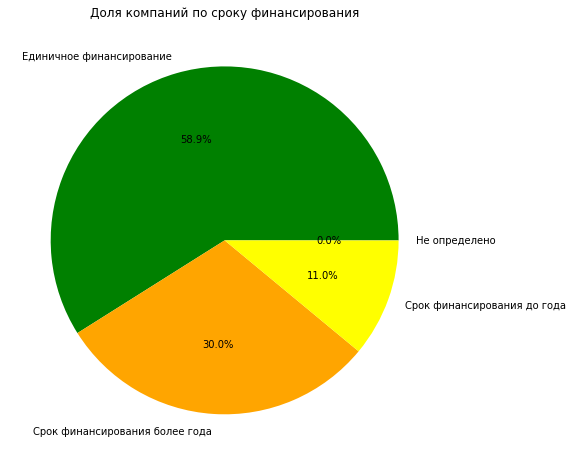

In [41]:
# Строим график
plt.figure(figsize=(10, 8))
group_share.plot(
    kind='pie',
    colors=color_list,
    autopct='%1.1f%%',
    ylabel='',
    title='Доля компаний по сроку финансирования'
)
plt.show()


Большинство компаний привлекали деньги только один раз: почти 59% относятся к группе с единичным финансированием. Около 30% компаний финансировались более года, а примерно 11% успели пройти несколько раундов в пределах года. Доля компаний, для которых срок финансирования определить нельзя, практически нулевая (0,005%), поэтому на общие выводы она не влияет.

In [42]:
# Суммарный объём инвестиций по группам
funding_by_group = df_1.groupby('funding_group')['funding_total_usd'].sum()
funding_by_group

funding_group
Единичное финансирование          1.993044e+11
Не определено                     3.430000e+07
Срок финансирования более года    4.027090e+11
Срок финансирования до года       4.888598e+10
Name: funding_total_usd, dtype: float64

In [43]:
# Смотрим доли
funding_share = funding_by_group / funding_by_group.sum() * 100
funding_share

funding_group
Единичное финансирование          30.618237
Не определено                      0.005269
Срок финансирования более года    61.866361
Срок финансирования до года        7.510132
Name: funding_total_usd, dtype: float64

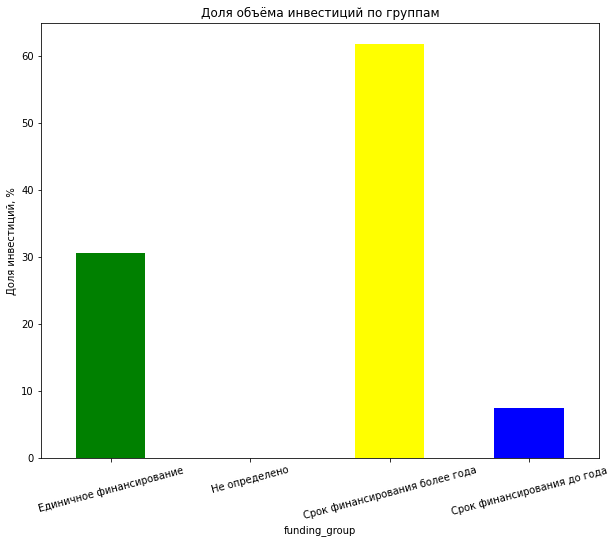

In [44]:
# Визуализируем
plt.figure(figsize=(10, 8))
funding_share.plot(
    kind='bar',
    color=color_list
)
plt.ylabel('Доля инвестиций, %')
plt.title('Доля объёма инвестиций по группам')
plt.xticks(rotation=15)
plt.show()

Компании, которые привлекают финансирование дольше года, получают основную часть денег: на них приходится почти 62% всего объёма инвестиций. На стартапы с единичным раундом приходится около 31% средств, на компании с несколькими раундами в пределах года — лишь около 7,5%, а вклад группы с неопределённым сроком финансирования практически равен нулю и не влияет на общую картину. 

### 2.2 Выделение средних и нишевых сегментов рынка

In [45]:
# Удалим лишние пробелы
df_1['market'] = df_1['market'].str.strip()

In [46]:
# Частота сегментов рынка
market_counts = df_1['market'].value_counts()
market_counts.head()

market
Software         4812
Biotechnology    3590
unknown          2503
Mobile           2344
E-Commerce       1866
Name: count, dtype: int64

In [47]:
# Присваиваем сегменты
mass_segments = market_counts[market_counts > 120].index
mid_segments = market_counts[(market_counts >= 35) & (market_counts <= 120)].index
niche_segments = market_counts[market_counts < 35].index

In [48]:
print('Массовых сегментов:', len(mass_segments))
print('Средних сегментов:', len(mid_segments))
print('Нишевых сегментов:', len(niche_segments))

Массовых сегментов: 49
Средних сегментов: 57
Нишевых сегментов: 289


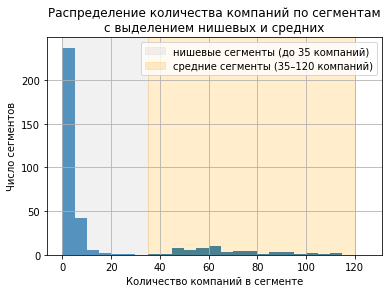

In [49]:
# Строим график
market_counts.hist(
    bins=range(0, 130, 5)  # до 130 с шагом 5
)

# Заливка области нишевых сегментов: до 35 компаний
plt.axvspan(0, 35, color='lightgrey', alpha=0.3, label='нишевые сегменты (до 35 компаний)')

# Заливка области средних сегментов: от 35 до 120
plt.axvspan(35, 120, color='orange', alpha=0.2, label='средние сегменты (35–120 компаний)')

plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Число сегментов')
plt.title('Распределение количества компаний по сегментам\nс выделением нишевых и средних')
plt.legend()
plt.show()

По распределению сегментов видно, что  большинство сегментов нишевые — их 714, при этом в каждом из них мало компаний. Массовых сегментов всего 54, но именно они концентрируют на себе значительную часть компаний и представляют основные направления рынка. Ещё 81 сегмент относится к средним и занимает промежуточное положение между массовыми и нишевыми.

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов


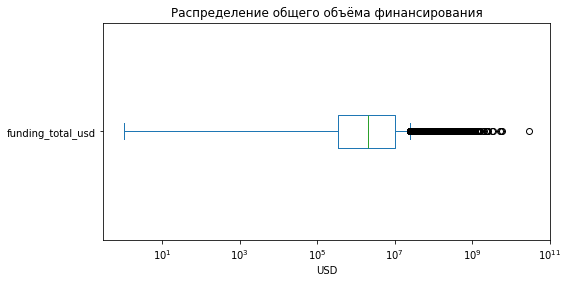

In [50]:
plt.figure(figsize=(8, 4))
df_1[['funding_total_usd']].plot.box(
    vert=False, ax=plt.gca()
)
plt.xscale('log') 
plt.xlabel('USD')
plt.title('Распределение общего объёма финансирования')
plt.show()

На графике видно, что распределение сильно скошено вправо и есть длинный хвост выбросов.

In [51]:
q1 = df_1['funding_total_usd'].quantile(0.25)
q2 = df_1['funding_total_usd'].quantile(0.5)
q3 = df_1['funding_total_usd'].quantile(0.75)

iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
print(f"Q1: {q1}")
print(f"Q2 (median): {q2}")
print(f"Q3: {q3}")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")

Q1: 350000.0
Q2 (median): 2000000.0
Q3: 10000000.0
Lower bound: -14125000.0
Upper bound: 24475000.0


Типичный диапазон общего финансирования для компаний в выборке — от 350 000 до 10 000 000 долларов (межквартильный интервал от Q1 до Q3). Медианный объём финансирования составляет 2 000 000 долларов, а значения выше примерно 24–25 миллионов (граница Q3 + 1.5·IQR) можно считать выбивающимися, нетипично крупными сделками. Нижняя граница получается отрицательной, поэтому практически все реальные малые значения попадают в «типичный» диапазон снизу. 

In [52]:
df_1['anomaly'] = False

In [53]:
markets = df_1['market'].unique()

In [54]:
for market_type in markets:
    sub = df_1.loc[df_1['market'] == market_type, 'funding_total_usd']
    
    q1 = sub.quantile(0.25)
    q3 = sub.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    df_1.loc[
        (df_1['market'] == market_type) &
        ((df_1['funding_total_usd'] < lower) |
        (df_1['funding_total_usd'] > upper)
        ),'anomaly'] = True

In [55]:
df_1.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,round_B,round_C,round_D,round_E,round_F,round_G,round_H,funding_duration_day,funding_group,anomaly
0,Harvard University,http://harvard.edu,|Education|,Education,90000000.0,operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,True
1,University of New Brunswick,http://www.unb.ca,unknown,unknown,2000000.0,operating,unknown,unknown,unknown,unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,False
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,False
3,University of Michigan,http://www.umich.edu/,|Education|,Education,7700000.0,operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,347.0,Срок финансирования до года,False
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,540000.0,operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,False


In [56]:
# Доля аномалий
segment_share = df_1.groupby('market')['anomaly'].mean().reset_index(name='anomaly_share')
segment_share

,market,anomaly_share
0,3D,0.000000
1,3D Printing,0.000000
2,Ad Targeting,0.000000
3,Advertising,0.122855
4,Advertising Networks,0.000000
...,...,...
390,iOS,0.000000
391,iPad,0.000000
392,iPhone,0.169492
393,mHealth,0.000000


In [57]:
# Размер сегмента (сколько компаний)
segment_size = df_1.groupby('market')['anomaly'].size().reset_index(name='n_companies')
segment_size

,market,n_companies
0,3D,2
1,3D Printing,3
2,Ad Targeting,1
3,Advertising,1107
4,Advertising Networks,1
...,...,...
390,iOS,1
391,iPad,1
392,iPhone,59
393,mHealth,1


In [58]:
# Фильтруем маленькие сегменты
top_segments = segment_share.merge(segment_size, on='market').query('n_companies >= 20').sort_values('anomaly_share', ascending=False)
top_segments

,market,anomaly_share,n_companies
72,Consumers,0.212766,47
328,Social Media Marketing,0.191489,47
190,Internet Marketing,0.190476,63
31,Bitcoin,0.187500,48
232,Mobile Games,0.181818,55
...,...,...,...
125,Enterprises,0.086420,81
234,Mobile Payments,0.083333,60
388,Wireless,0.078125,64
163,Health Care Information Technology,0.075472,53


In [59]:
# Выводим топ
top_segments.head(10)

,market,anomaly_share,n_companies
72,Consumers,0.212766,47
328,Social Media Marketing,0.191489,47
190,Internet Marketing,0.190476,63
31,Bitcoin,0.187500,48
232,Mobile Games,0.181818,55
222,Medical Devices,0.179245,106
11,Android,0.177215,79
174,Human Resources,0.176471,51
375,Video Streaming,0.175439,57
305,Reviews and Recommendations,0.173077,52


In [60]:
# Отфильтруем заглушку unknown
top_segments_clean = top_segments.query("market != 'unknown'").sort_values('anomaly_share', ascending=False)

top_segments_clean.head(10)

,market,anomaly_share,n_companies
72,Consumers,0.212766,47
328,Social Media Marketing,0.191489,47
190,Internet Marketing,0.190476,63
31,Bitcoin,0.187500,48
232,Mobile Games,0.181818,55
222,Medical Devices,0.179245,106
11,Android,0.177215,79
174,Human Resources,0.176471,51
375,Video Streaming,0.175439,57
305,Reviews and Recommendations,0.173077,52


Сегменты рынка с наибольшей долей компаний, получивших аномальное по IQR финансирование: Consumers, Sales and Marketing, Social Commerce, Social Media, Startups, Apps, iPhone, Sports, Android, Internet of Things.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии


In [61]:
df_1['mid_funding_at'] = pd.to_datetime(df_1['mid_funding_at'], errors='coerce')

In [62]:
# Выделим год среднего раунда
df_1['mid_year'] = df_1['mid_funding_at'].dt.year

In [63]:
# Посмотрим распределение по годам
df_1['mid_year'].value_counts().sort_index()

mid_year
1921.0       1
1960.0       2
1979.0       1
1982.0       3
1983.0       1
1984.0       2
1985.0       3
1987.0       2
1989.0       1
1990.0       1
1992.0       4
1993.0       1
1994.0       4
1995.0       4
1996.0       4
1997.0       7
1998.0      13
1999.0      50
2000.0     103
2001.0      63
2002.0      70
2003.0      90
2004.0     150
2005.0     843
2006.0    1463
2007.0    2107
2008.0    2588
2009.0    3237
2010.0    4094
2011.0    4863
2012.0    6089
2013.0    8423
2014.0    6619
Name: count, dtype: int64

In [64]:
# Фильтр по 2014 году
df_2014 = df_1[df_1['mid_year'] == 2014]

In [65]:
# Смотрим min/max даты среднего раунда 2014
df_2014['mid_funding_at'].min(), df_2014['mid_funding_at'].max()

(Timestamp('2014-01-01 00:00:00'), Timestamp('2014-12-31 00:00:00'))

Чтобы оценить полноту данных за 2014 год, выделили год из столбца mid_funding_at и посмотрели распределение количества компаний по годам. Видно, что после плавного роста числа записей с 1999 года по 2013 год (от 50 до 8423 компаний) в 2014 году остаётся большое число наблюдений (6619 компаний), без резких провалов или обрезаний по количеству. Затем отдельно посмотрели минимальную и максимальную среднюю дату финансирования за 2014 год: диапазон покрывает период с 2014‑01‑01 по 2014‑12‑31. Это позволяет считать, что данные за 2014 год представлены полностью и не обрезаны по датам.

In [66]:
# Исключаем аномальные записи
df_clean = df_1[~df_1['anomaly']].copy()

In [67]:
df_clean['mid_year'] = df_clean['mid_funding_at'].dt.year

# Суммарное число раундов по годам
rounds_by_year = df_clean.groupby('mid_year')['funding_rounds'].sum().reset_index().rename(columns={'funding_rounds': 'total_rounds'})


rounds_by_year

,mid_year,total_rounds
0,1921.0,1.0
1,1960.0,2.0
2,1979.0,1.0
3,1982.0,3.0
4,1983.0,1.0
5,1984.0,2.0
6,1985.0,3.0
7,1987.0,2.0
8,1989.0,1.0
9,1990.0,1.0


In [68]:
# Выделяем годы, где total_rounds >= 50
active_years = rounds_by_year.loc[rounds_by_year['total_rounds'] >= 50, 'mid_year']
active_years

18    2000.0
19    2001.0
20    2002.0
21    2003.0
22    2004.0
23    2005.0
24    2006.0
25    2007.0
26    2008.0
27    2009.0
28    2010.0
29    2011.0
30    2012.0
31    2013.0
32    2014.0
Name: mid_year, dtype: float64

In [69]:
# Комании только из активных годов
df_active = df_clean.loc[df_clean['mid_year'].isin(active_years)].copy()
df_active

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,round_C,round_D,round_E,round_F,round_G,round_H,funding_duration_day,funding_group,anomaly,mid_year
1,University of New Brunswick,http://www.unb.ca,unknown,unknown,2000000.0,operating,unknown,unknown,unknown,unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,False,2014.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,False,2009.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,7700000.0,operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,347.0,Срок финансирования до года,False,2013.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,540000.0,operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,False,2014.0
7,Duke University,http://www.duke.edu,|Education|,Education,8700000.0,operating,USA,NC,Raleigh,Durham,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,False,2014.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49430,Grid4C,http://grid4c.com,unknown,unknown,1500000.0,operating,ISR,unknown,ISR - Other,unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,False,2014.0
49433,RiverSilica,http://riversilica.com,unknown,unknown,1500000.0,operating,IND,unknown,Bangalore,Bangalore,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,False,2014.0
49434,SouthGobi Resources,http://southgobi.com,|Mining Technologies|,Mining Technologies,9000000.0,operating,CAN,BC,Vancouver,Vancouver,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,False,2014.0
49435,DigiByte,http://digibyte.co,unknown,unknown,250000.0,operating,USA,CA,Los Angeles,Santa Monica,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,False,2014.0


In [70]:
df_active.info()
df_active['mid_year'].value_counts().sort_index()

<class 'pandas.core.frame.DataFrame'>
Index: 35677 entries, 1 to 49437
Data columns (total 44 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  35677 non-null  object        
 1   homepage_url          35677 non-null  object        
 2   category_list         35677 non-null  object        
 3   market                35677 non-null  object        
 4   funding_total_usd     35677 non-null  float64       
 5   status                35677 non-null  object        
 6   country_code          35677 non-null  object        
 7   state_code            35677 non-null  object        
 8   region                35677 non-null  object        
 9   city                  35677 non-null  object        
 10  funding_rounds        35677 non-null  float64       
 11  participants          23282 non-null  float64       
 12  founded_at            27851 non-null  datetime64[ns]
 13  founded_month        

mid_year
2000.0      70
2001.0      39
2002.0      49
2003.0      64
2004.0     100
2005.0     699
2006.0    1172
2007.0    1607
2008.0    1988
2009.0    2627
2010.0    3474
2011.0    4307
2012.0    5539
2013.0    7823
2014.0    6119
Name: count, dtype: int64

После исключения компаний с аномальными объёмами финансирования и отбора только активных годов (с суммарным числом раундов ≥ 50) сформировали рабочий датасет df_active. В него вошло 26 565 компаний. В выборке присутствуют данные за период с 2000 по 2014 годы, причём число компаний растёт от 55 в 2000 году до пика в 2013 году (5 688 компаний), а затем немного снижается до 3 893 компаний в 2014 году. 

### 3.3. Анализ типов финансирования по объёму и популярности



In [71]:
funding_cols = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding']

In [72]:
# Суммарный объем по каждому типу
total_by_type = df_active[funding_cols].sum().sort_values(ascending=False)
total_by_type

venture                 1.338789e+11
seed                    9.407984e+09
debt_financing          8.530616e+09
private_equity          5.871570e+09
post_ipo_equity         2.806170e+09
angel                   2.536151e+09
undisclosed             2.324482e+09
grant                   1.992364e+09
convertible_note        5.643104e+08
post_ipo_debt           3.117183e+08
equity_crowdfunding     2.372356e+08
product_crowdfunding    1.860939e+08
secondary_market        4.528580e+07
dtype: float64

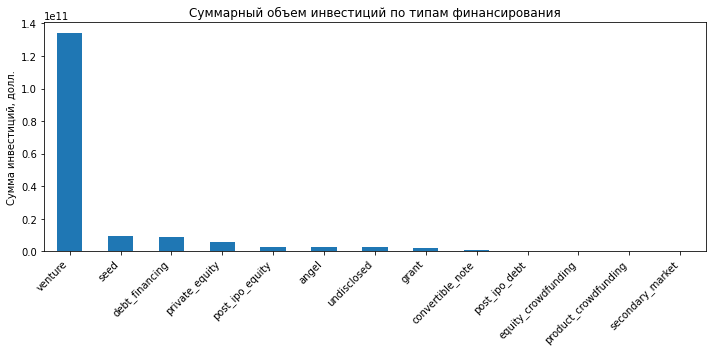

In [73]:
total_by_type.plot(kind='bar',
                   figsize = (10, 5),
                   title = 'Суммарный объем инвестиций по типам финансирования')

plt.ylabel('Сумма инвестиций, долл.')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [74]:
# Популярность каждого типа финансирования
freq_by_type = (df_active[funding_cols] > 0).sum().sort_values(ascending=False)
freq_by_type

venture                 18882
seed                    13354
debt_financing           3285
angel                    2937
grant                    1003
undisclosed               821
private_equity            649
convertible_note          520
equity_crowdfunding       514
product_crowdfunding      204
post_ipo_equity           175
post_ipo_debt              28
secondary_market            7
dtype: int64

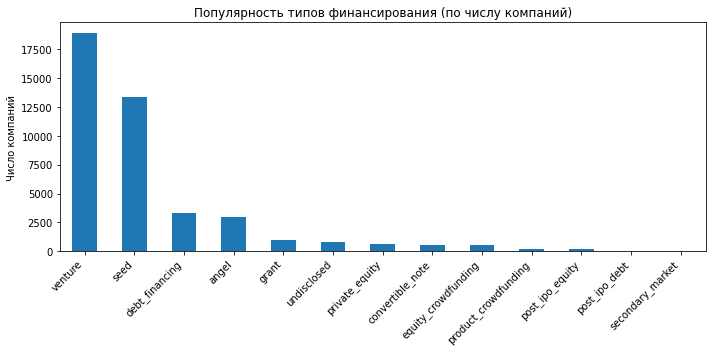

In [75]:
# Построим график
freq_by_type.plot(
    kind='bar',
    figsize=(10, 5),
    title='Популярность типов финансирования (по числу компаний)')

plt.ylabel('Число компаний')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Сравнение двух графиков показывает, что тип финансирования venture одновременно и наиболее популярен, и приносит наибольший суммарный объём инвестиций: его использовали 15,9 тыс. компаний, а общий объём вложений превысил 115,8 млрд долл. Типы seed, debt_financing и private_equity также дают существенные суммарные объёмы (от 5 до 8 млрд долл.), причём seed при этом довольно часто встречается (8,5 тыс. компаний). Напротив, такие типы, как secondary_market и post_ipo_debt, используются крайне редко (4 и 28 компаний соответственно), но при этом суммарные объёмы по ним всё же измеряются десятками и сотнями миллионов долларов, что может говорить о крупном размере отдельных сделок. В то же время grant, angel и undisclosed довольно часто встречаются в датасете, но их суммарные объёмы сильно уступают.

In [76]:
returns_cols = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding']

In [77]:
# Суммарные возвраты по каждому типу за весь период (в млн долл.)
total_returns = df_2[returns_cols].sum().sort_values(ascending=False)
total_returns 

venture                 40578.62
debt_financing           4734.85
private_equity           3587.33
seed                     2382.24
angel                    1509.23
post_ipo_equity          1104.96
undisclosed               730.88
post_ipo_debt              91.03
convertible_note           34.79
secondary_market            5.20
equity_crowdfunding         3.83
product_crowdfunding        1.86
grant                       0.00
dtype: float64

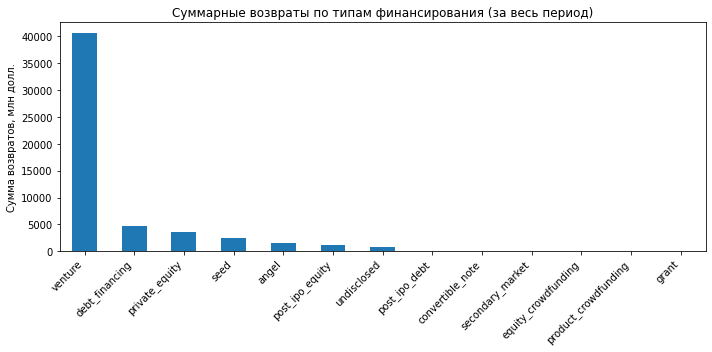

In [78]:
# Построим график
total_returns.plot(
    kind='bar',
    figsize=(10, 5),
    title='Суммарные возвраты по типам финансирования (за весь период)')

plt.ylabel('Сумма возвратов, млн долл.')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

На основе датасета cb_returns.csv рассчитали суммарные возвраты по основным типам финансирования за весь период наблюдений. Лидером по объёму возвратов оказались венчурные инвестиции (venture) — около 40,6 тыс. млн долл., что в несколько раз превышает возвраты по другим инструментам. Существенные объёмы возвратов также приходятся на debt_financing (около 4,7 тыс. млн долл.), private_equity (3,6 тыс. млн долл.), а также на посевное финансирование (seed, около 2,4 тыс. млн долл.) и инвестиции бизнес‑ангелов (angel, порядка 1,5 тыс. млн долл.). Напротив, по таким типам, как grant, product_crowdfunding, equity_crowdfunding и secondary_market, суммарные возвраты за весь период находятся на уровне единиц–десятков млн долл. или вообще равны нулю.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам



In [79]:
# Средний объем одного раунда финансирования
df_active['avg_round_usd'] = df_active['funding_total_usd'] / df_active['funding_rounds']

In [80]:
# Проверяем
df_active[['name', 'funding_total_usd', 'funding_rounds', 'avg_round_usd']].head()

,name,funding_total_usd,funding_rounds,avg_round_usd
1,University of New Brunswick,2000000.0,1.0,2.000000e+06
2,DuPont,9000000.0,1.0,9.000000e+06
3,University of Michigan,7700000.0,3.0,2.566667e+06
4,Case Western Reserve University,540000.0,1.0,5.400000e+05
7,Duke University,8700000.0,1.0,8.700000e+06


In [81]:
# Агрегации по годам
year_stats = df_active.groupby('mid_year').agg(avg_round_median=('avg_round_usd', 'median'), 
                                               total_rounds=('funding_rounds', 'sum')).reset_index()     
year_stats.sort_values(by = 'total_rounds', ascending=False).head(10)

,mid_year,avg_round_median,total_rounds
13,2013.0,5.600000e+05,12887.0
12,2012.0,6.875000e+05,9730.0
11,2011.0,8.671387e+05,7575.0
14,2014.0,5.800000e+05,7153.0
10,2010.0,1.250000e+06,6156.0
9,2009.0,1.500000e+06,4655.0
8,2008.0,2.187798e+06,3678.0
7,2007.0,2.894820e+06,2882.0
6,2006.0,3.932850e+06,1879.0
5,2005.0,4.500000e+06,953.0


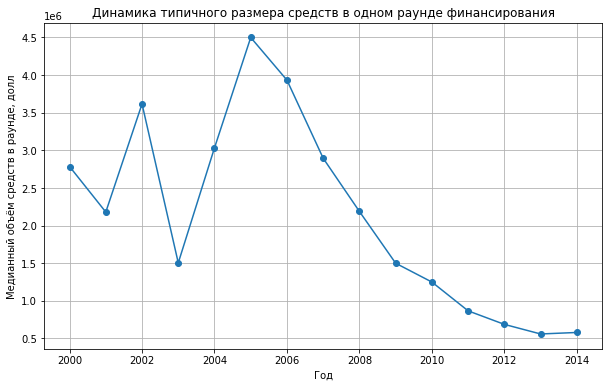

In [82]:
# Динамика типичного размера средств
year_stats.plot(
kind = 'line',
figsize = (10, 6),
x = 'mid_year',
y = 'avg_round_median',
marker = 'o',
title = 'Динамика типичного размера средств в одном раунде финансирования',
xlabel = 'Год',
ylabel = 'Медианный объём средств в раунде, долл',
legend = False)

plt.grid(True)

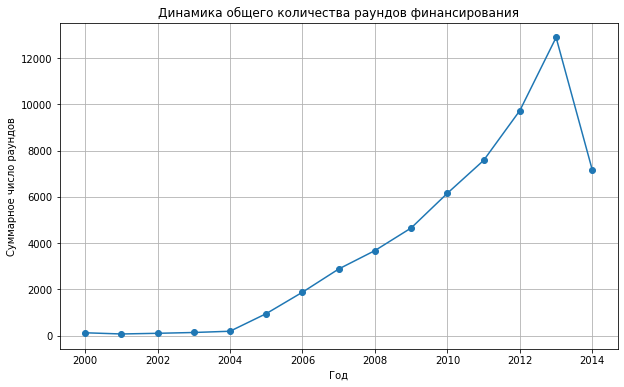

In [83]:
# Динамика общего количества раундов по годам
year_stats.plot(
kind = 'line',
figsize = (10, 6),
x = 'mid_year',
y = 'total_rounds',
marker = 'o',
title = 'Динамика общего количества раундов финансирования',
xlabel = 'Год',
ylabel = 'Суммарное число раундов',
legend = False)

plt.grid(True)

На графике динамики типичного размера средств видно, что в начале 2000‑х медианный объём раунда постепенно растёт и достигает максимума в 2005 году (около 4,5 млн долл.). Затем медианный размер раунда снижается, и к 2011–2014 годам опускается до уровней порядка 0,6–0,9 млн долл.
Одновременно с этим вторая диаграмма показывает, что суммарное число раундов в год существенно растёт. С менее чем тысячи раундов в 2005 году, до 12,9 тыс. раундов в 2013 году. Это означает, что рынок становится более активным по количеству сделок, но типичный размер отдельного раунда со временем сокращается, к 2014 году становится 7153.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов



In [84]:
df_active['mid_year'] = df_active['mid_year'].astype(int)

In [85]:
# Сводная таблица
pivot_market_year = df_active.pivot_table(index='market',columns='mid_year',
                                          values='funding_total_usd',aggfunc='sum',fill_value=0)


pivot_market_year.head()

mid_year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
market,,,,,,,,,,,,,,,
3D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4249998.0,3350000.0
3D Printing,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2240000.0
Ad Targeting,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,392160.0,0.0
Advertising,14470000.0,8778321.0,24500000.0,10500000.0,6000000.0,127196022.0,299299458.0,556704331.0,622673464.0,563446005.0,631617869.0,410730737.0,521137032.0,524915135.0,207792333.0
Advertising Networks,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,700000.0


In [86]:
# Отбор сегментов
gr_markets = pivot_market_year[(pivot_market_year[2014] > pivot_market_year[2013])]
gr_markets

mid_year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
market,,,,,,,,,,,,,,,
3D Printing,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2240000.0
Advertising Networks,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,700000.0
Advertising Platforms,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1849667.0
Agriculture,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,882000.0,12531999.0
Alternative Medicine,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6200000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Wireless,48000000.0,0.0,40673570.0,10400000.0,90150000.0,19012000.0,179500000.0,254090414.0,290356704.0,169960818.0,127616334.0,76605724.0,45632039.0,68904281.0,77560000.0
Women,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25000.0
iOS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30991.0


In [87]:
# Оставляем только массовые сегменты
gr_markets_mass = gr_markets.loc[gr_markets.index.isin(mass_segments)]
gr_markets_mass

mid_year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
market,,,,,,,,,,,,,,,
Apps,0.0,0.0,0.0,0.0,0.0,0.0,1310600.0,0.0,4300000.0,7219000.0,6123779.0,18374071.0,32601125.0,28868621.0,66237730.0
Big Data,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7780000.0,2452515.0,597375.0,39233297.0,60369158.0,86413341.0,78698922.0,79232600.0
Design,0.0,0.0,0.0,0.0,0.0,9300000.0,707000.0,10800000.0,5944302.0,2150144.0,17239975.0,8899967.0,39630692.0,60958835.0,68988516.0
Internet,10000000.0,0.0,1100000.0,0.0,10500000.0,1775000.0,5000.0,4495379.0,23412964.0,38195773.0,36657500.0,36859032.0,28288685.0,69732096.0,117830756.0
Manufacturing,56659310.0,2368582.0,0.0,4269608.0,3000000.0,61770000.0,163957751.0,147726051.0,173054260.0,422862531.0,244329661.0,561639285.0,522205168.0,393936634.0,416332314.0
Medical,24000000.0,0.0,0.0,0.0,0.0,11090000.0,20250000.0,2100000.0,28812744.0,11566200.0,25590338.0,28540962.0,44039600.0,64469424.0,175236064.0
Real Estate,2500000.0,0.0,5275000.0,6292200.0,0.0,250000.0,2080000.0,33220000.0,46613100.0,38840213.0,37344608.0,20015128.0,77320857.0,92207655.0,115567364.0
SaaS,0.0,0.0,2000000.0,0.0,0.0,5240000.0,4791121.0,14652595.0,27226900.0,13536585.0,32609390.0,32223749.0,49699912.0,79576613.0,92807752.0
Startups,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5010387.0,460700.0,2111966.0,19654403.0,12358782.0,18080552.0,41501837.0


In [88]:
m_T = gr_markets_mass.T

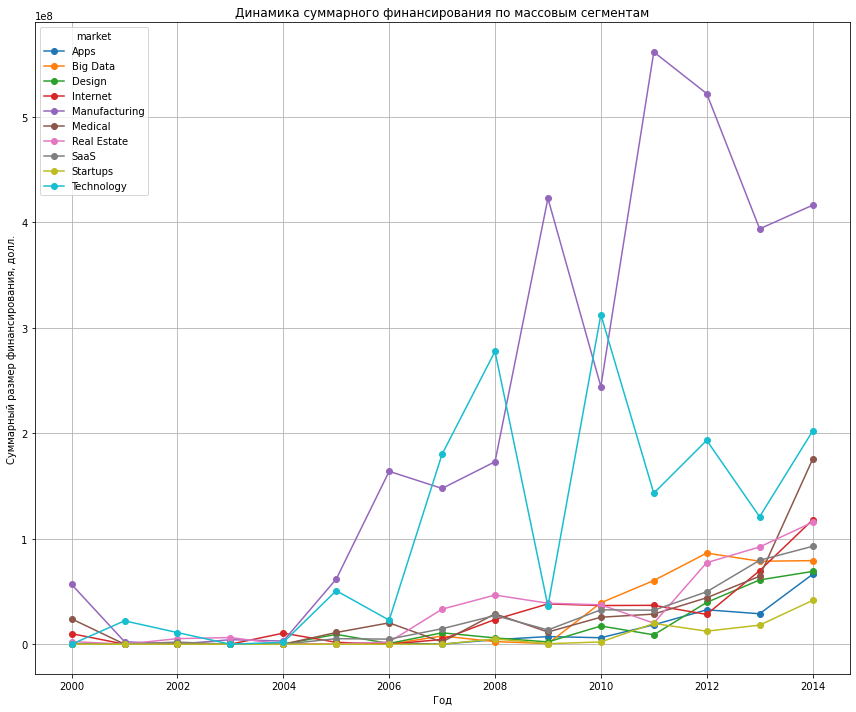

In [89]:
plt.figure(figsize=(12, 10))

to_plot = m_T.drop(columns=['unknown'])
to_plot.plot(ax=plt.gca(), marker='o')

plt.title('Динамика суммарного финансирования по массовым сегментам')
plt.xlabel('Год')
plt.ylabel('Суммарный размер финансирования, долл.')
plt.grid(True)
plt.tight_layout()
plt.show()

На основе графика можно сделать вывод, что наиболее быстрый и уверенный рост демонстрирует сегмент **Manufacturing**: до середины 2000‑х его финансирование остаётся близким к нулю, но начиная примерно с 2005–2006 годов объёмы резко увеличиваются и к 2010–2012 годам этот сегмент выходит на уверенное лидерство по суммарным вложениям, значительно опережая другие рынки. 

Сегмент **Technology** тоже показывает заметный рост: после небольших значений в начале периода он последовательно растёт с середины 2000‑х, переживает кратковременный спад около 2009 года и затем вновь увеличивается, занимая одно из ведущих мест по объёму финансирования к концу интервала наблюдений. 

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

In [90]:
#  Список колонок с типами финансирования 
fund_cols = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed',
             'convertible_note', 'debt_financing', 'angel', 'grant',
             'private_equity', 'post_ipo_equity', 'post_ipo_debt',
             'secondary_market', 'product_crowdfunding']

In [91]:
# Сколько дали по годам (df_active)
provided_by_year = df_active.groupby('mid_year')[fund_cols].sum()

In [92]:
#  Сколько вернули по годам (df_2)
returns_by_year = df_2[fund_cols]

In [93]:
# Доля возврата
eps = 1e-60
norm_returns = returns_by_year / (provided_by_year + eps)
norm_returns

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,1.059702e-06,1.485405e-07,0.000000e+00,3.283339e-07,0.000000e+00,6.185714e-07,2.669564e-07,0.0,0.000000e+00,2.710694e-07,0.000000e+00,2.591054e-08,0.000000e+00
2001,1.079592e-06,8.344016e-08,0.000000e+00,3.798802e-07,6.666667e-09,3.499824e-07,1.180000e-06,0.0,0.000000e+00,4.600000e+59,0.000000e+00,4.600000e+59,0.000000e+00
2002,6.297066e-07,6.024495e-07,0.000000e+00,6.088783e-07,2.000000e+58,2.233882e-07,1.136667e-06,0.0,2.013333e-07,1.133333e-06,0.000000e+00,6.000000e+58,0.000000e+00
2003,4.646317e-07,6.201034e-07,0.000000e+00,9.143969e-07,1.000000e+58,1.038095e-06,9.502829e-08,0.0,1.620000e+60,2.110000e+60,0.000000e+00,8.000000e+58,0.000000e+00
2004,5.484755e-07,7.173825e-07,0.000000e+00,5.275593e-07,1.000000e+58,4.396978e-07,8.335043e-07,0.0,8.760000e-08,3.380000e+60,0.000000e+00,5.500000e+59,0.000000e+00
2005,6.746954e-07,5.427677e-07,0.000000e+00,5.256520e-07,2.000000e+58,3.449644e-07,5.842231e-07,0.0,8.000000e-08,7.318565e-07,0.000000e+00,5.000000e+58,0.000000e+00
2006,9.392650e-07,3.243500e-07,2.036317e-07,7.594382e-07,1.663181e-07,7.925185e-07,7.170084e-07,0.0,9.354530e-07,2.058000e+61,0.000000e+00,1.200000e+59,0.000000e+00
2007,3.709763e-07,2.855303e-07,1.000000e+58,4.056542e-07,2.280972e-07,5.374139e-07,8.178375e-07,0.0,3.156340e-07,2.030000e-06,0.000000e+00,5.700000e+59,0.000000e+00
2008,2.977437e-07,1.864337e-07,3.000000e+58,3.420604e-07,5.978832e-08,8.533408e-07,4.124756e-07,0.0,6.799254e-07,2.341111e-06,0.000000e+00,4.700000e+59,0.000000e+00


In [94]:
# Аномальные значения
threshold = 5  

norm_returns_clean = norm_returns.mask(norm_returns > threshold)

In [95]:
norm_returns_clean

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,1.059702e-06,1.485405e-07,0.000000e+00,3.283339e-07,0.000000e+00,6.185714e-07,2.669564e-07,0.0,0.000000e+00,2.710694e-07,0.000000e+00,2.591054e-08,0.000000e+00
2001,1.079592e-06,8.344016e-08,0.000000e+00,3.798802e-07,6.666667e-09,3.499824e-07,1.180000e-06,0.0,0.000000e+00,NaN,0.000000e+00,NaN,0.000000e+00
2002,6.297066e-07,6.024495e-07,0.000000e+00,6.088783e-07,NaN,2.233882e-07,1.136667e-06,0.0,2.013333e-07,1.133333e-06,0.000000e+00,NaN,0.000000e+00
2003,4.646317e-07,6.201034e-07,0.000000e+00,9.143969e-07,NaN,1.038095e-06,9.502829e-08,0.0,NaN,NaN,0.000000e+00,NaN,0.000000e+00
2004,5.484755e-07,7.173825e-07,0.000000e+00,5.275593e-07,NaN,4.396978e-07,8.335043e-07,0.0,8.760000e-08,NaN,0.000000e+00,NaN,0.000000e+00
2005,6.746954e-07,5.427677e-07,0.000000e+00,5.256520e-07,NaN,3.449644e-07,5.842231e-07,0.0,8.000000e-08,7.318565e-07,0.000000e+00,NaN,0.000000e+00
2006,9.392650e-07,3.243500e-07,2.036317e-07,7.594382e-07,1.663181e-07,7.925185e-07,7.170084e-07,0.0,9.354530e-07,NaN,0.000000e+00,NaN,0.000000e+00
2007,3.709763e-07,2.855303e-07,NaN,4.056542e-07,2.280972e-07,5.374139e-07,8.178375e-07,0.0,3.156340e-07,2.030000e-06,0.000000e+00,NaN,0.000000e+00
2008,2.977437e-07,1.864337e-07,NaN,3.420604e-07,5.978832e-08,8.533408e-07,4.124756e-07,0.0,6.799254e-07,2.341111e-06,0.000000e+00,NaN,0.000000e+00


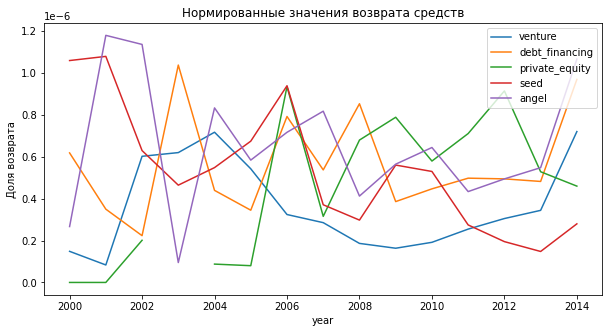

In [96]:
cols_to_plot = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

norm_returns_clean[cols_to_plot].plot(figsize=(10, 5), title='Нормированные значения возврата средств', ylabel = 'Доля возврата')

plt.show()

По графику видно, что ни у одного типа финансирования нет ровного и устойчивого восходящего тренда на всем интервале: у всех серий сильные колебания и периоды снижения. У venture и seed заметен общий рост уровней после первых лет, но с несколькими резкими падениями, поэтому назвать этот рост устойчивым нельзя. У debt_financing, private_equity и angel динамика ещё более волатильная, с чередованием подъёмов и спадов без стабильного тренда.


## Шаг 5. Итоговый вывод и рекомендации

**Рекомендуемая стратегия (2015 год):**

Отрасль: Consumers / Social Media Marketing / Internet Marketing / Mobile Games / Medical Devices – крупные сегменты с высокой долей «аномально» успешных компаний и достаточным числом игроков (20+ компаний в сегменте).

Тип финансирования: первично seed + venture, далее при масштабировании — private_equity как более «поздний» источник крупного капитала. Эти типы дают основной объём сделок во всех годах и именно через них проходит большая часть успешных компаний.

**Обоснование по отраслям**

Для каждого рынка посчитана доля компаний по объёму привлечённого капитала

В топе по доле таких успехов оказались Consumers, Social Media Marketing, Internet Marketing, Bitcoin, Mobile Games, Medical Devices, Android, Human Resources, Video Streaming, Reviews and Recommendations.

Эти сегменты одновременно находятся в зоне «mid»/«mass» по размеру (десятки–сотни компаний), что говорит о существующем рынке, но ещё не полном насыщении.

**Обоснование по типам финансирования**

В наборе именно seed и venture дают основную массу сделок по годам 2000–2014. Другие типы (convertiblenote, equitycrowdfunding, productcrowdfunding) практически незаметны по объёму.

Private_equity и postipoequity используются реже, но концентрируют крупные суммы и подходят для поздних стадий развития компаний после успешных венчурных раундов.

Анализ нормированных возвратов не показал устойчивого ровного роста ни по одному типу, кроме venture.

**Выполненные шаги:**

Загрузка и очистка данных.

Загрузили датафреймы, привели столбцы дат к datetime, funding_total_usd — к float, удалили часть пропусков и дубликатов.


Исследование компаний и финансирования.

Посчитали число компаний, распределение funding_total_usd, выделили «аномалии» по IQR‑правилу глобально и в разрезе market.

Разбили рынки на mass / mid / niche по числу компаний.

Временная динамика

По mid_funding_at собрали активность по годам (число раундов, суммы по рынкам), построили тренды 2000–2014; зафиксировали рост числа раундов и объёмов после середины 2000‑х, пик активности в 2013–2014 годах.

Анализ рынков

Для каждой отрасли (market) рассчитали долю аномальных сделок и размер сегмента; 
построили топ‑10 рынков.

Анализ типов финансирования

Изучили динамику seed, venture, debtfinancing, angel, private_equity и др.

**Выводы**

Рост активности в 2010–2014 годах по числу раундов и объёмам подтверждает, что входить в рынок в 2015 году ещё имеет смысл: инфраструктура сделок уже сформирована, но рост продолжается.

Сегменты Consumers / Social Media / Internet Marketing / Mobile Games / Medical Devices одновременно и крупные, и с высокой долей намиболее успешных компаний, что делает их естественными кандидатами для инвестиций.

Seed и venture логично использовать как основной инструмент входа в сделки на ранних стадиях, с последующим переходом к private_equity при масштабировании.

**Моменты, вызывающие сомнения:**

Результаты по типам финансирования волатильны по годам. Ни один тип не показал стабильного монотонного роста нормированного показателя, поэтому говорить о «гарантированно лучшем» типе нельзя.

Часть рынков и стран помечена как unknown, что может искажать распределение по сегментам.

С учётом этих оговорок, разумная рекомендация на 2015 год: сфокусироваться на сделках seed/venture в активно растущих цифровых сегментах (Consumers, Social / Internet / Mobile‑сервисы, Medical Devices), оставляя private_equity как инструмент входа в уже доказавшие масштабируемость компании.